In [194]:
import sklearn 
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as mtp

In [195]:
whole_data=pd.read_csv('train.csv')

In [196]:
whole_data.head(5)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


checking for null value

In [197]:
whole_data.isnull().sum()

ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

data exploration and transformation

In [198]:
whole_data.rename(columns={'austim':'autisum_in_family'},inplace=True)

In [199]:
whole_data.keys()

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'autisum_in_family', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='str')

In [200]:
#whole_data['age']=whole_data['age'].astype(int)

In [201]:
whole_data['age'].values

array([38.17274623, 47.7505168 ,  7.38037308, 23.56192742, 43.20579044,
       31.5279644 , 28.42797076, 26.48449442, 48.20345856, 24.16794517,
       21.49703144,  9.04422584, 56.00816807, 21.0875973 , 29.14538397,
       31.27199413, 23.73476684, 28.63694334, 14.4049851 , 72.83887066,
       25.06830214, 15.36750123, 41.95517061, 21.05567436, 14.12910836,
       54.49860242, 26.59264047, 26.42977485, 12.84159731,  9.66220855,
       30.50058819, 74.87051104, 26.07964814, 67.00819233, 22.46984114,
       30.94822637, 24.92914563, 24.94160486, 11.88213606, 26.75778566,
       44.32227347, 74.53450864, 23.58363906, 25.64110026, 22.57022313,
       35.73551276, 22.41443272, 30.19192183, 47.59591916,  7.57244956,
       17.34629766, 41.22877555, 18.70249321,  6.9287435 , 41.8240423 ,
       46.08667963, 23.63397697, 48.35947059, 42.6822189 , 21.53439758,
       21.47758213, 35.23448231, 51.91718291, 14.05691123, 13.56674871,
       38.91852862, 16.33264533, 17.52426083, 44.34770684, 37.98

In [202]:
from sklearn.preprocessing import LabelEncoder
jaundice_occer=LabelEncoder()
whole_data['jaundice']=jaundice_occer.fit_transform(whole_data['jaundice'])


In [203]:
jaundice_data=whole_data['jaundice'].value_counts()
jaundice_data

jaundice
0    615
1    185
Name: count, dtype: int64

In [204]:
whole_data['ethnicity'].value_counts()

ethnicity
White-European     257
?                  203
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
others               3
Name: count, dtype: int64

In [205]:
count=0
for i in whole_data['ethnicity']:
  if i == "?":
   count+=1
print(count)


203


In [206]:
whole_data['ethnicity']=whole_data['ethnicity'].replace("?","Other_Country")

In [207]:
whole_data.head(6)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,autisum_in_family,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,Other_Country,0,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,Other_Country,0,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,0,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,Other_Country,0,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,Other_Country,0,no,South Africa,no,-4.777286,18 and more,Self,0
5,6,1,0,0,0,0,1,0,0,1,...,m,Middle Eastern,0,no,Jordan,no,9.562117,18 and more,Self,0


In [208]:
whole_data.keys()

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'autisum_in_family', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='str')

In [209]:
whole_data['gender'].value_counts()

gender
m    530
f    270
Name: count, dtype: int64

In [210]:
whole_data['age_desc'].value_counts()

age_desc
18 and more    800
Name: count, dtype: int64

In [211]:
whole_data['relation'].value_counts()

relation
Self                        709
?                            40
Parent                       29
Relative                     18
Others                        2
Health care professional      2
Name: count, dtype: int64

In [212]:
whole_data['relation']=whole_data['relation'].replace({'?':'Others'})

In [213]:
whole_data['relation'].value_counts()

relation
Self                        709
Others                       42
Parent                       29
Relative                     18
Health care professional      2
Name: count, dtype: int64

In [214]:
whole_data['contry_of_res'].value_counts()

contry_of_res
United States           134
India                   108
New Zealand              78
United Kingdom           67
Jordan                   55
United Arab Emirates     40
Australia                37
Canada                   30
Afghanistan              22
Netherlands              20
Austria                  18
Sri Lanka                17
Brazil                   12
Kazakhstan               10
France                   10
Spain                    10
Ireland                   9
Iran                      8
Russia                    7
South Africa              6
Malaysia                  6
Italy                     6
Bahamas                   6
Viet Nam                  5
Iraq                      4
AmericanSamoa             4
Saudi Arabia              4
Aruba                     4
Azerbaijan                4
Armenia                   4
China                     4
Pakistan                  4
Mexico                    4
Nicaragua                 4
Ukraine                   3
Bolivi

In [215]:
whole_data['autisum_in_family']=whole_data['autisum_in_family'].replace({'no':'0','yes':'1'})

In [216]:
whole_data['used_app_before']=whole_data['used_app_before'].replace({'no':'0','yes':'1'})

In [217]:
whole_data['gender']=whole_data['gender'].map({'m':1,'f':0})

In [218]:
whole_data.head(5)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,autisum_in_family,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,0,Other_Country,0,0,Austria,0,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,1,Other_Country,0,0,India,0,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,1,White-European,0,1,United States,0,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,0,Other_Country,0,0,United States,0,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,1,Other_Country,0,0,South Africa,0,-4.777286,18 and more,Self,0


scale age and result data for better result

In [219]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

whole_data[['age','result']] = scaler.fit_transform(whole_data[['age','result']])

In [220]:
whole_data.head(5)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,autisum_in_family,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,0,Other_Country,0,0,Austria,0,0.567913,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,1,Other_Country,0,0,India,0,0.381655,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,1,White-European,0,1,United States,0,0.954452,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,0,Other_Country,0,0,United States,0,0.382630,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,1,Other_Country,0,0,South Africa,0,0.061865,18 and more,Self,0


**data visualization**

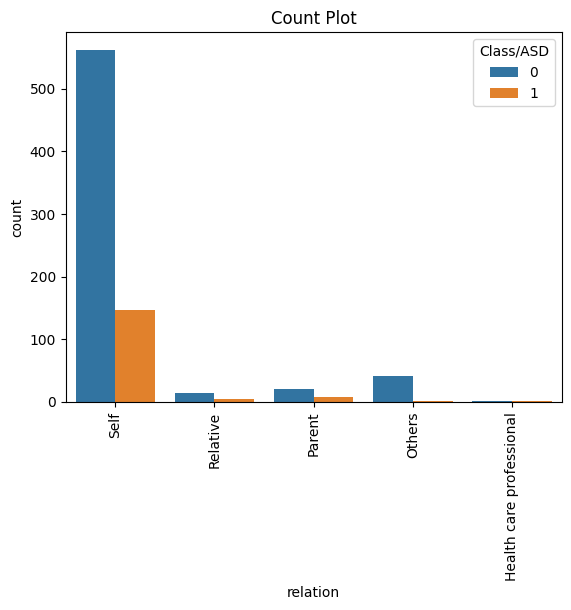

In [221]:
sb.countplot(x=whole_data['relation'],hue='Class/ASD',data=whole_data)
mtp.title("Count Plot")
mtp.tick_params(axis='x', rotation=90)
mtp.show()

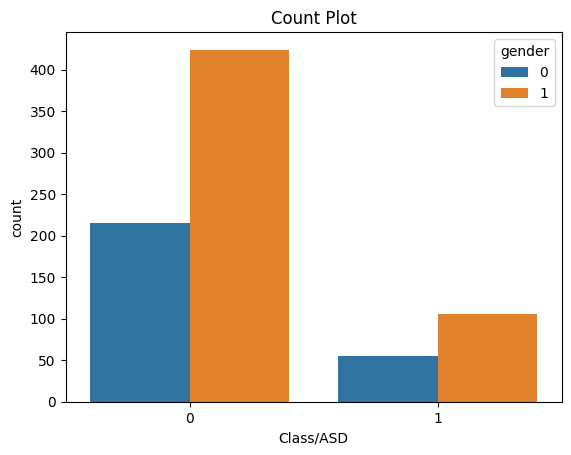

In [222]:
sb.countplot(x='Class/ASD',hue=whole_data['gender'],data=whole_data)
mtp.title("Count Plot")
mtp.show()

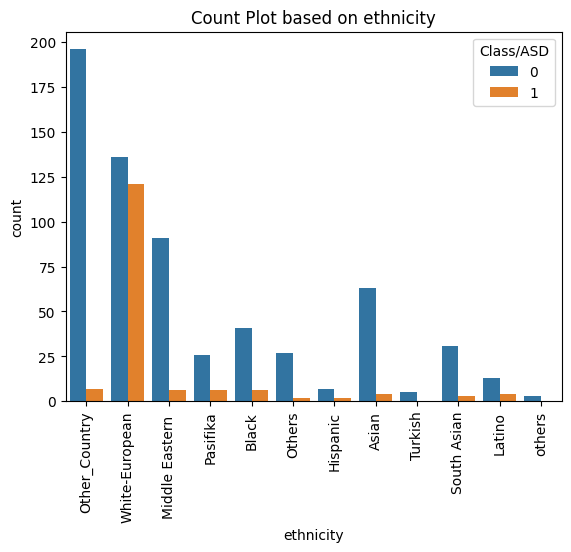

In [223]:
sb.countplot(x=whole_data['ethnicity'],hue='Class/ASD',data=whole_data)
mtp.title("Count Plot based on ethnicity")
mtp.tick_params(axis='x', rotation=90)
mtp.show()

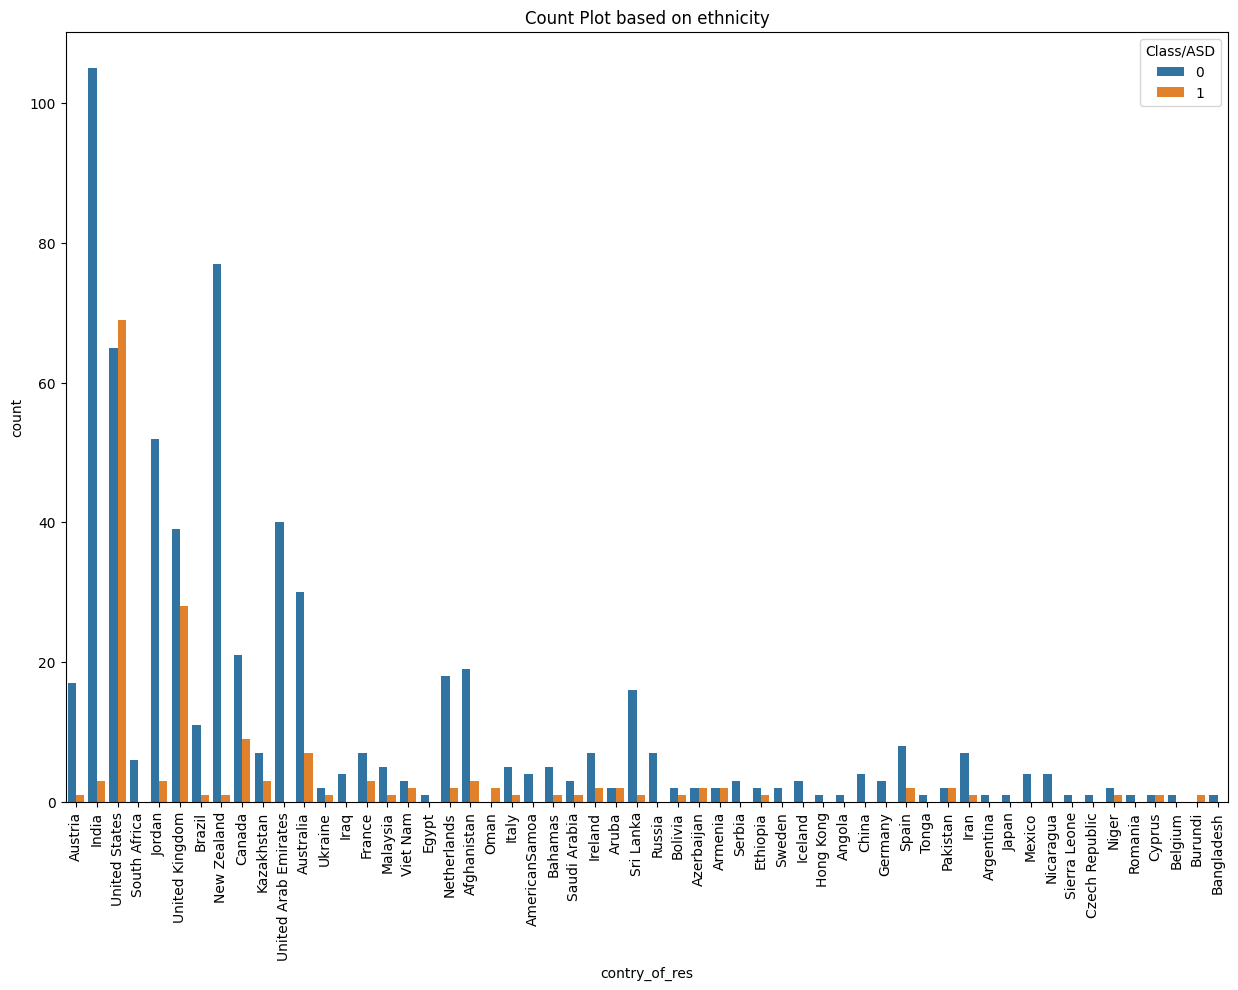

In [224]:
mtp.figure(figsize=(15,10))
sb.countplot(x=whole_data['contry_of_res'],hue='Class/ASD',data=whole_data)
mtp.title("Count Plot based on ethnicity")
mtp.tick_params(axis='x', rotation=90)
mtp.show()

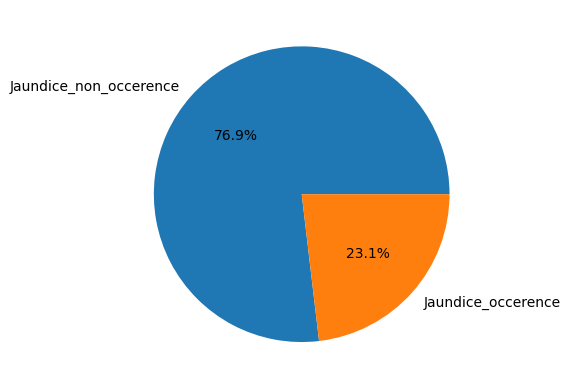

In [225]:
lebles=['Jaundice_non_occerence','Jaundice_occerence']
mtp.pie(jaundice_data,labels=lebles,autopct='%1.1f%%')

mtp.show()

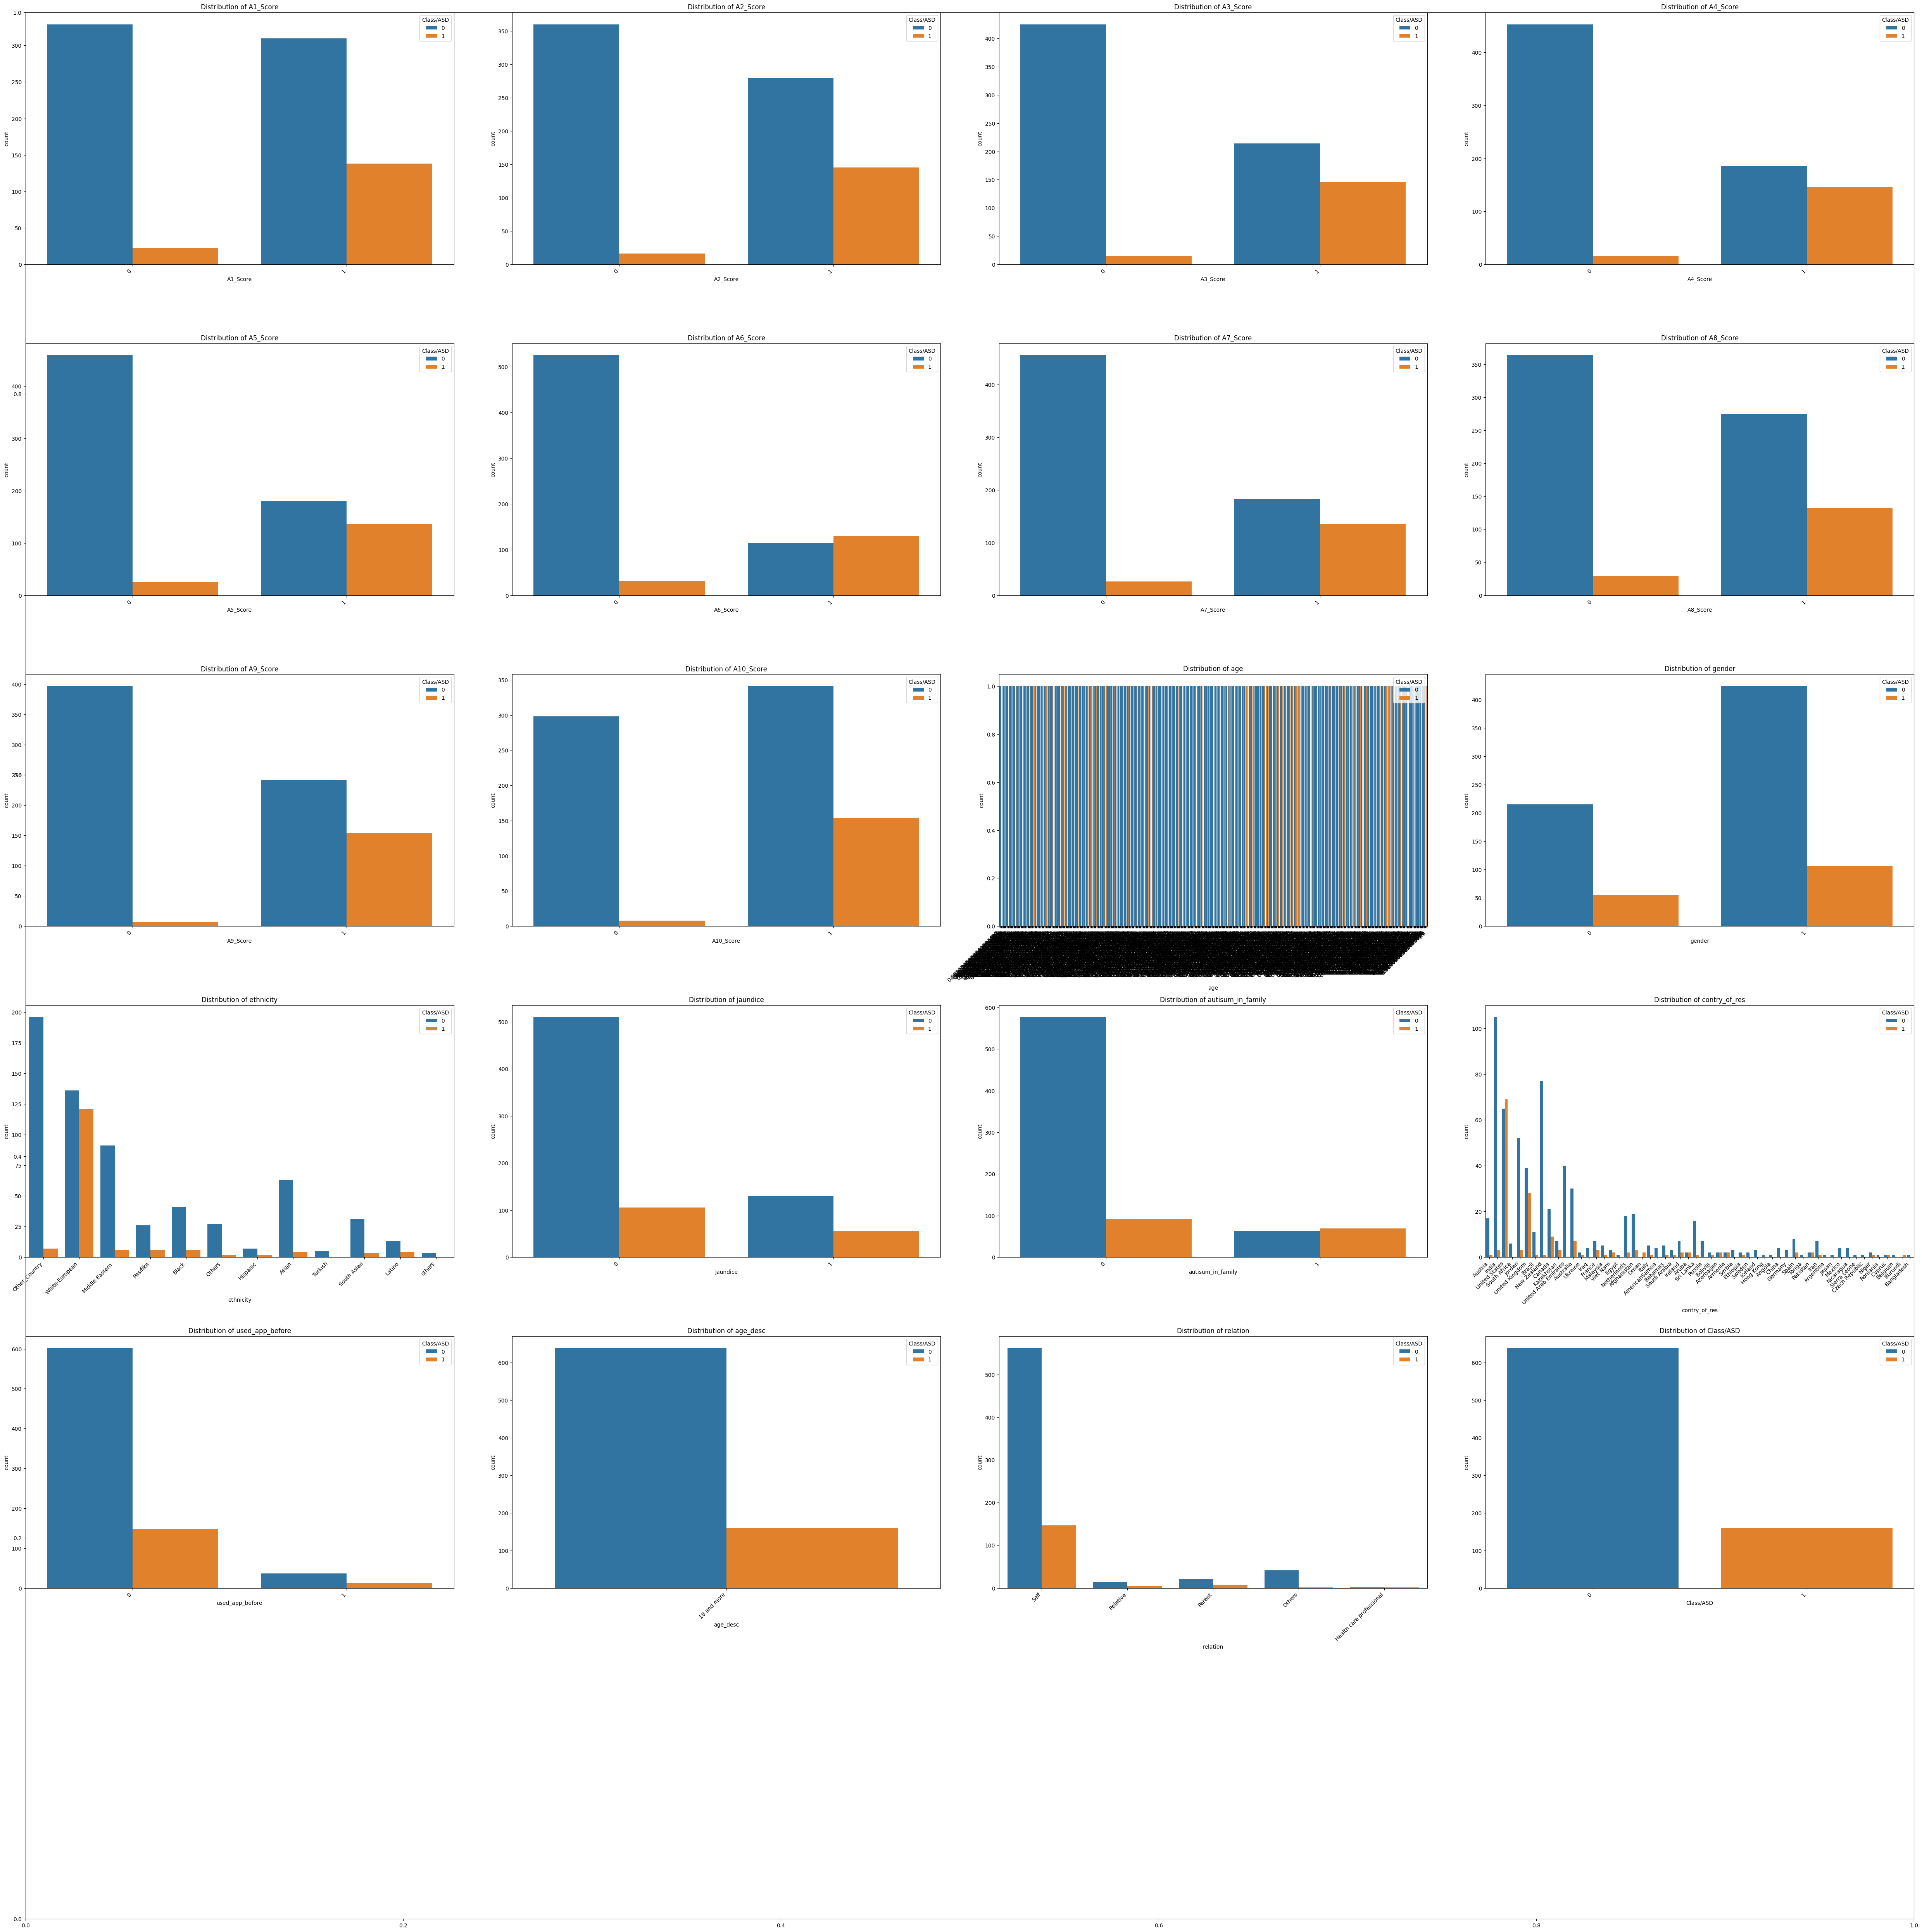

In [226]:
mtp.subplots(figsize=(50, 50))  # Adjust figure size as needed

for i, col in enumerate((whole_data.drop(['ID','result'],axis=1)).columns):
    mtp.subplot(6, 4, i + 1)  # Adjusted subplot grid to 6 rows, 4 columns
    sb.countplot(x=col, hue='Class/ASD', data=whole_data)
    mtp.title(f'Distribution of {col}')
    mtp.xticks(rotation=45, ha='right') # Rotates x-axis labels for better readability

mtp.tight_layout()
mtp.show()

data cleaning

In [227]:
#removal useless attribute

In [228]:
whole_data.drop(['autisum_in_family','used_app_before','contry_of_res','ethnicity','age_desc', 'result','relation','ID'],axis=1,inplace=True)

In [229]:
whole_data.tail(5)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,jaundice,Class/ASD
795,0,1,0,0,0,0,0,0,1,1,0.159997,1,0,0
796,0,1,1,0,0,1,0,1,1,1,0.207330,1,0,0
797,0,0,0,0,0,0,0,0,0,0,0.034503,1,1,0
798,0,0,0,0,0,0,0,0,0,0,0.157889,0,0,0
799,0,1,0,0,0,0,0,0,0,0,0.510099,0,0,0


In [230]:
x=whole_data.drop('Class/ASD',axis=1)
y=whole_data['Class/ASD']

In [231]:
x

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,jaundice
0,1,0,1,0,1,0,1,0,1,1,0.408726,0,0
1,0,0,0,0,0,0,0,0,0,0,0.519141,1,0
2,1,1,1,1,1,1,1,1,1,1,0.053743,1,0
3,0,0,0,0,0,0,0,0,0,0,0.240288,0,0
4,0,0,0,0,0,0,0,0,0,0,0.466748,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0,1,0,0,0,0,0,0,1,1,0.159997,1,0
796,0,1,1,0,0,1,0,1,1,1,0.207330,1,0
797,0,0,0,0,0,0,0,0,0,0,0.034503,1,1
798,0,0,0,0,0,0,0,0,0,0,0.157889,0,0


In [232]:
y

0      0
1      0
2      1
3      0
4      0
      ..
795    0
796    0
797    0
798    0
799    0
Name: Class/ASD, Length: 800, dtype: int64

**split the data**

In [233]:
from sklearn.model_selection import train_test_split


In [234]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [235]:
y_train.value_counts()

Class/ASD
0    515
1    125
Name: count, dtype: int64

In [236]:
y_test.value_counts()

Class/ASD
0    124
1     36
Name: count, dtype: int64

**using LogisticRegression model**

In [237]:
from sklearn.linear_model import LogisticRegression

In [238]:
model2=LogisticRegression(max_iter=1000)

In [239]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model2, x_train, y_train, cv=5)

print(scores)
print("Average:", scores.mean())

[0.8984375 0.8515625 0.859375  0.84375   0.8359375]
Average: 0.8578125


In [240]:
model2.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [241]:
predic_y2=model2.predict(x_test)
predic_y2

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [242]:
predic_y2[0:25]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1])

In [243]:
y_test.values[0:25]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0])

In [244]:
pd.DataFrame(predic_y2)

,0
0,0
1,0
2,0
3,0
4,0
...,...
155,0
156,0
157,0
158,0


In [245]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
print(f"\nthe accuracy of logistic regression is {accuracy_score(y_test,predic_y2)}")
print(f"\nthe classification report of logistic regression is \n{classification_report(y_test,predic_y2)}")
print(f"\nthe confusion matrix of logistic regression is \n {confusion_matrix(y_test,predic_y2)}")


the accuracy of logistic regression is 0.8625

the classification report of logistic regression is 
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       124
           1       0.73      0.61      0.67        36

    accuracy                           0.86       160
   macro avg       0.81      0.77      0.79       160
weighted avg       0.86      0.86      0.86       160


the confusion matrix of logistic regression is 
 [[116   8]
 [ 14  22]]


**using DecisionTreeClassifier model**

In [246]:
from sklearn.tree import DecisionTreeClassifier
model3=DecisionTreeClassifier()

In [247]:


scores = cross_val_score(model3, x_train, y_train, cv=5)

print(scores)
print("Average:", scores.mean())

[0.7890625 0.8046875 0.796875  0.828125  0.8046875]
Average: 0.8046875


In [248]:
model3.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [249]:
predic_y3=model3.predict(x_test)
predic_y3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [250]:
print(f"the accuracy of decision tree is {accuracy_score(y_test,predic_y3)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,predic_y3)}")
print(f"the confusion matrix of decision tree is \n {confusion_matrix(y_test,predic_y3)}")

the accuracy of decision tree is 0.7875
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       124
           1       0.53      0.53      0.53        36

    accuracy                           0.79       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.79      0.79      0.79       160

the confusion matrix of decision tree is 
 [[107  17]
 [ 17  19]]


**using RandomForestClassifier model**

In [251]:
from sklearn.ensemble import RandomForestClassifier
model4=RandomForestClassifier()

In [252]:


scores = cross_val_score(model4, x_train, y_train, cv=5)

print(scores)
print("Average:", scores.mean())

[0.8671875 0.875     0.859375  0.8203125 0.8125   ]
Average: 0.846875


In [253]:
model4.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [254]:
predic_y4=model4.predict(x_test)
predic_y4

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [255]:
print(f"the accuracy of decision tree is {accuracy_score(y_test,predic_y4)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,predic_y4)}")
print(f"the confusion matrix of decision tree is \n {confusion_matrix(y_test,predic_y4)}")

the accuracy of decision tree is 0.80625
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.84      0.92      0.88       124
           1       0.60      0.42      0.49        36

    accuracy                           0.81       160
   macro avg       0.72      0.67      0.69       160
weighted avg       0.79      0.81      0.79       160

the confusion matrix of decision tree is 
 [[114  10]
 [ 21  15]]


**using SVC model**

In [256]:
from sklearn.svm import SVC
model5=SVC()

In [257]:


scores = cross_val_score(model5, x_train, y_train, cv=5)

print(scores)
print("Average:", scores.mean())

[0.875     0.8828125 0.859375  0.8203125 0.8515625]
Average: 0.8578125


In [258]:
model5.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [259]:
predic_y5=model5.predict(x_test)
predic_y5

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [260]:
print(f"the accuracy of decision tree is {accuracy_score(y_test,predic_y5)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,predic_y5)}")
print(f"the confusion matrix of decision tree is \n {confusion_matrix(y_test,predic_y5)}")

the accuracy of decision tree is 0.86875
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       124
           1       0.74      0.64      0.69        36

    accuracy                           0.87       160
   macro avg       0.82      0.79      0.80       160
weighted avg       0.86      0.87      0.87       160

the confusion matrix of decision tree is 
 [[116   8]
 [ 13  23]]


**using smoth balance to the imbalance data and again get the accuracy**


In [261]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_smoth,y_train_smoth=smote.fit_resample(x_train,y_train)

In [262]:
y_train_smoth.value_counts()

Class/ASD
1    515
0    515
Name: count, dtype: int64

In [263]:
x_train_smoth.value_counts()

A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  A8_Score  A9_Score  A10_Score  age       gender  jaundice
1         1         1         1         1         1         1         1         1         1          0.877544  1       0           1
0         0         0         0         0         0         1         1         0         0          0.078083  1       0           1
1         0         0         0         0         0         0         0         0         0          0.332104  1       0           1
0         0         0         0         0         0         0         0         0         0          0.309480  1       0           1
1         1         0         1         0         0         0         0         1         1          0.315062  0       0           1
                                                                                                                                  ..
                    1         0         1         1         1         0   

In [264]:
model2=LogisticRegression(max_iter=1000)

In [265]:
model2.fit(x_train_smoth,y_train_smoth)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [266]:
smoth_y_pred2=model2.predict(x_test)
smoth_y_pred2

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [267]:
smoth_y_pred2_=pd.DataFrame(smoth_y_pred2)

In [268]:
smoth_y_pred2_.value_counts()

0
0    102
1     58
Name: count, dtype: int64

In [269]:
y_test.value_counts()

Class/ASD
0    124
1     36
Name: count, dtype: int64

In [270]:
print(f"the accuracy of logistic regression is {accuracy_score(y_test,smoth_y_pred2)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,smoth_y_pred2)}")

the accuracy of logistic regression is 0.8125
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.96      0.79      0.87       124
           1       0.55      0.89      0.68        36

    accuracy                           0.81       160
   macro avg       0.76      0.84      0.77       160
weighted avg       0.87      0.81      0.83       160



In [271]:
model3=DecisionTreeClassifier(


     )

In [272]:
model3.fit(x_train_smoth,y_train_smoth)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [273]:
smoth_y_pred3=model3.predict(x_test)
smoth_y_pred3

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [274]:
y_test.values

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [275]:
smoth_y_pred3_=pd.DataFrame(smoth_y_pred3)

In [276]:
smoth_y_pred3_.value_counts()


0
0    118
1     42
Name: count, dtype: int64

In [277]:
print(f"the accuracy of decision tree is {accuracy_score(y_test,smoth_y_pred3)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,smoth_y_pred3)}")

the accuracy of decision tree is 0.8
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       124
           1       0.55      0.64      0.59        36

    accuracy                           0.80       160
   macro avg       0.72      0.74      0.73       160
weighted avg       0.81      0.80      0.81       160



In [278]:
model4.fit(x_train_smoth,y_train_smoth)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [279]:
smoth_y_pred4=model3.predict(x_test)
smoth_y_pred4

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [280]:
y_test.values

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [281]:
print(f"the accuracy of random forest is {accuracy_score(y_test,smoth_y_pred4)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,smoth_y_pred4)}")

the accuracy of random forest is 0.8
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       124
           1       0.55      0.64      0.59        36

    accuracy                           0.80       160
   macro avg       0.72      0.74      0.73       160
weighted avg       0.81      0.80      0.81       160



In [282]:
model5.fit(x_train_smoth,y_train_smoth)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [283]:
smoth_y_pred5=model5.predict(x_test)
smoth_y_pred5


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [284]:
y_test.values

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0])

In [285]:
print(f"the accuracy of random forest is {accuracy_score(y_test,smoth_y_pred5)}")
print(f"the classification report of decision tree is \n {classification_report(y_test,smoth_y_pred5)}")

the accuracy of random forest is 0.8125
the classification report of decision tree is 
               precision    recall  f1-score   support

           0       0.93      0.82      0.87       124
           1       0.56      0.78      0.65        36

    accuracy                           0.81       160
   macro avg       0.74      0.80      0.76       160
weighted avg       0.84      0.81      0.82       160



### Hyperparameter Tuning using RandomizedSearchCV

Now, let's use `RandomizedSearchCV` to find optimal hyperparameters for the `RandomForestClassifier`.

In [286]:
from sklearn.model_selection import RandomizedSearchCV



param_dist = {

    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}



# Function for hyperparameter tuning
def hyperparameter_tuning(model):
    random_search1 = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,   # reduced for faster execution
        cv=5,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )

    # Fit the model
    random_search1.fit(x_train_smoth, y_train_smoth)
    hyperpm_T_y_pred3=random_search1.predict(x_test)



    # Print results
    print("Model:", model)
    print("Best Parameters:", random_search1.best_params_)
    print("Best Score:", random_search1.best_score_)
    print(f"the accuracy of SVM is {accuracy_score(y_test,hyperpm_T_y_pred3)}")
    print(f"the classification report of SVM is \n {classification_report(y_test,hyperpm_T_y_pred3)}")
    print("-" * 50)
hyperparameter_tuning(model3)

Model: DecisionTreeClassifier()
Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5}
Best Score: 0.8712949516587342
the accuracy of SVM is 0.79375
the classification report of SVM is 
               precision    recall  f1-score   support

           0       0.93      0.80      0.86       124
           1       0.53      0.78      0.63        36

    accuracy                           0.79       160
   macro avg       0.73      0.79      0.74       160
weighted avg       0.84      0.79      0.81       160

--------------------------------------------------


In [287]:
from sklearn.model_selection import RandomizedSearchCV


# Define the parameter distribution (for RandomForest only)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

models = [model4]

# Function for hyperparameter tuning
def hyperparameter_tuning(model):
    random_search2 = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,   # reduced for faster execution
        cv=5,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )

    # Fit the model
    random_search2.fit(x_train_smoth, y_train_smoth)
    hyperpm_T_y_pred4=random_search2.predict(x_test)

    # Print results
    print("Model:", model)
    print("Best Parameters:", random_search2.best_params_)
    print("Best Score:", random_search2.best_score_)
    print(f"the accuracy of SVM is {accuracy_score(y_test,hyperpm_T_y_pred4)}")
    print(f"the classification report of SVM is \n {classification_report(y_test,hyperpm_T_y_pred4)}")
    print("-" * 50)


# Loop through all models (OUTSIDE the function)
for model in models:
    hyperparameter_tuning(model)

Model: RandomForestClassifier()
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Best Score: 0.9165524860389411
the accuracy of SVM is 0.83125
the classification report of SVM is 
               precision    recall  f1-score   support

           0       0.91      0.86      0.89       124
           1       0.60      0.72      0.66        36

    accuracy                           0.83       160
   macro avg       0.76      0.79      0.77       160
weighted avg       0.84      0.83      0.84       160

--------------------------------------------------


In [292]:
from sklearn.model_selection import RandomizedSearchCV


# Define the parameter distribution (for RandomForest only)
param_dist = {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
}



# Function for hyperparameter tuning
def hyperparameter_tuning(model):
    random_search3= RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,   # reduced for faster execution
        cv=5,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )

    # Fit the model
    random_search3.fit(x_train_smoth, y_train_smoth)
    hyperpm_T_y_pred5=random_search3.predict(x_test)

    # Print results
    print("Model:", model)
    print("Best Parameters:", random_search3.best_params_)
    print("Best Score:", random_search3.best_score_)
    print(f"the accuracy of SVM is {accuracy_score(y_test,hyperpm_T_y_pred5)}")
    print(f"the classification report of SVM is \n {classification_report(y_test,hyperpm_T_y_pred5)}")
    print("-" * 50)
    return random_search3


hyperparameter_tuning(model5)

Model: SVC()
Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best Score: 0.9138355529933184
the accuracy of SVM is 0.83125
the classification report of SVM is 
               precision    recall  f1-score   support

           0       0.92      0.85      0.89       124
           1       0.60      0.75      0.67        36

    accuracy                           0.83       160
   macro avg       0.76      0.80      0.78       160
weighted avg       0.85      0.83      0.84       160

--------------------------------------------------


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.

In [293]:
best_svm = hyperparameter_tuning(SVC())

Model: SVC()
Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best Score: 0.9138355529933184
the accuracy of SVM is 0.83125
the classification report of SVM is 
               precision    recall  f1-score   support

           0       0.92      0.85      0.89       124
           1       0.60      0.75      0.67        36

    accuracy                           0.83       160
   macro avg       0.76      0.80      0.78       160
weighted avg       0.85      0.83      0.84       160

--------------------------------------------------


#now try predicting using SVM becouse it has high f1_score almost high accuracy

In [289]:
new_data=pd.DataFrame([[0,1,1,1,1,1,1,0,1,1,0.38,0,1]],
                      columns=['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score'	,'age','gender','jaundice'	])

In [294]:
pred = best_svm.predict(new_data)


In [295]:
pred

array([1])

**means Model says the person has autisum**

In [297]:
import pickle
pickle.dump(best_svm,open('model5.pkl','wb'))
pickle.dump(whole_data,open('whole_data.pkl','wb'))